In [1]:
from google.cloud import bigquery
client_bq = bigquery.Client.from_service_account_json("../credentials.json", project='charged-dialect-824')

# Loading data from BQ

In [2]:
def load_bq_data(_sql):
    _df = client_bq.query(_sql).to_dataframe()
    return _df

In [3]:
sql = """
SELECT *
FROM RicardoInterview.product_detection_training_data
"""

df_load = load_bq_data(sql)
len(df_load)
df_load.head()

/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1933: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,articleId,title,subtitle,productType
0,-3393892867263864215,Gone Is Gone - Echolocation,Gone Is Gone - Echolocation,cd
1,-2831118468819601923,Ekseption-The Lost Last Concert Tapes...,The Lost Last Concert Tapes (Box-Set),cd
2,6835807414137785977,PORTISHEAD CD-Sammlung 3 CDs #16,Kollektion für Fans der Trip-Hop-Pioniere aus ...,cd
3,-4912458353746230865,Primeon CD-R Rohlinge (bunt),39 Stück auf der Spindel,cd
4,1496864991301777371,Adonia - Zmittst im Füür,Markus Hottiger / Markus Heusser,cd


# To be implemented

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import seaborn as sns

In [ ]:
# 2. Text Length Analysis
print(f'Before cleaning: {df_load.shape}')

df_load['combined_text'] = df_load['title'] + ' ' + df_load['subtitle']

df_load['title_length'] = df_load['title'].apply(len)
df_load['subtitle_length'] = df_load['subtitle'].apply(len)
df_load['combined_length'] = df_load['combined_text'].apply(len)

# Set all to lowercase and remove non-alphanumeric characters
df_load['subtitle'] = df_load['subtitle'].str.lower().str.replace('[^\w\s]', '', regex=True).fillna('')

# Remove rows with empty title or subtitle
df_load = df_load[df_load['title'].notna() & df_load['subtitle'].notna()]
df_load = df_load[df_load['title'] != '']
df_load = df_load[df_load['productType'] != '']

# Remove rows with empty productType
df_load = df_load[df_load['productType'].notna()]

# remove space in beginning and end of title and subtitle
df_load['title'] = df_load['title'].str.strip()
df_load['subtitle'] = df_load['subtitle'].str.strip()

# remove space in beginning and end of productType
df_load['productType'] = df_load['productType'].str.strip()


# After cleaning
print(f'After cleaning: {df_load.shape}')

Before cleaning: (37567, 6)
After cleaning: (37565, 8)


## Analysis

In [6]:
print(df_load['productType'].value_counts())

productType
radio_controlled_model    99
cd                        99
pc                        99
wc                        99
bag                       99
                          ..
holster                   63
handrail                  61
jukebox                   60
dump_truck                52
marble                    48
Name: count, Length: 383, dtype: int64


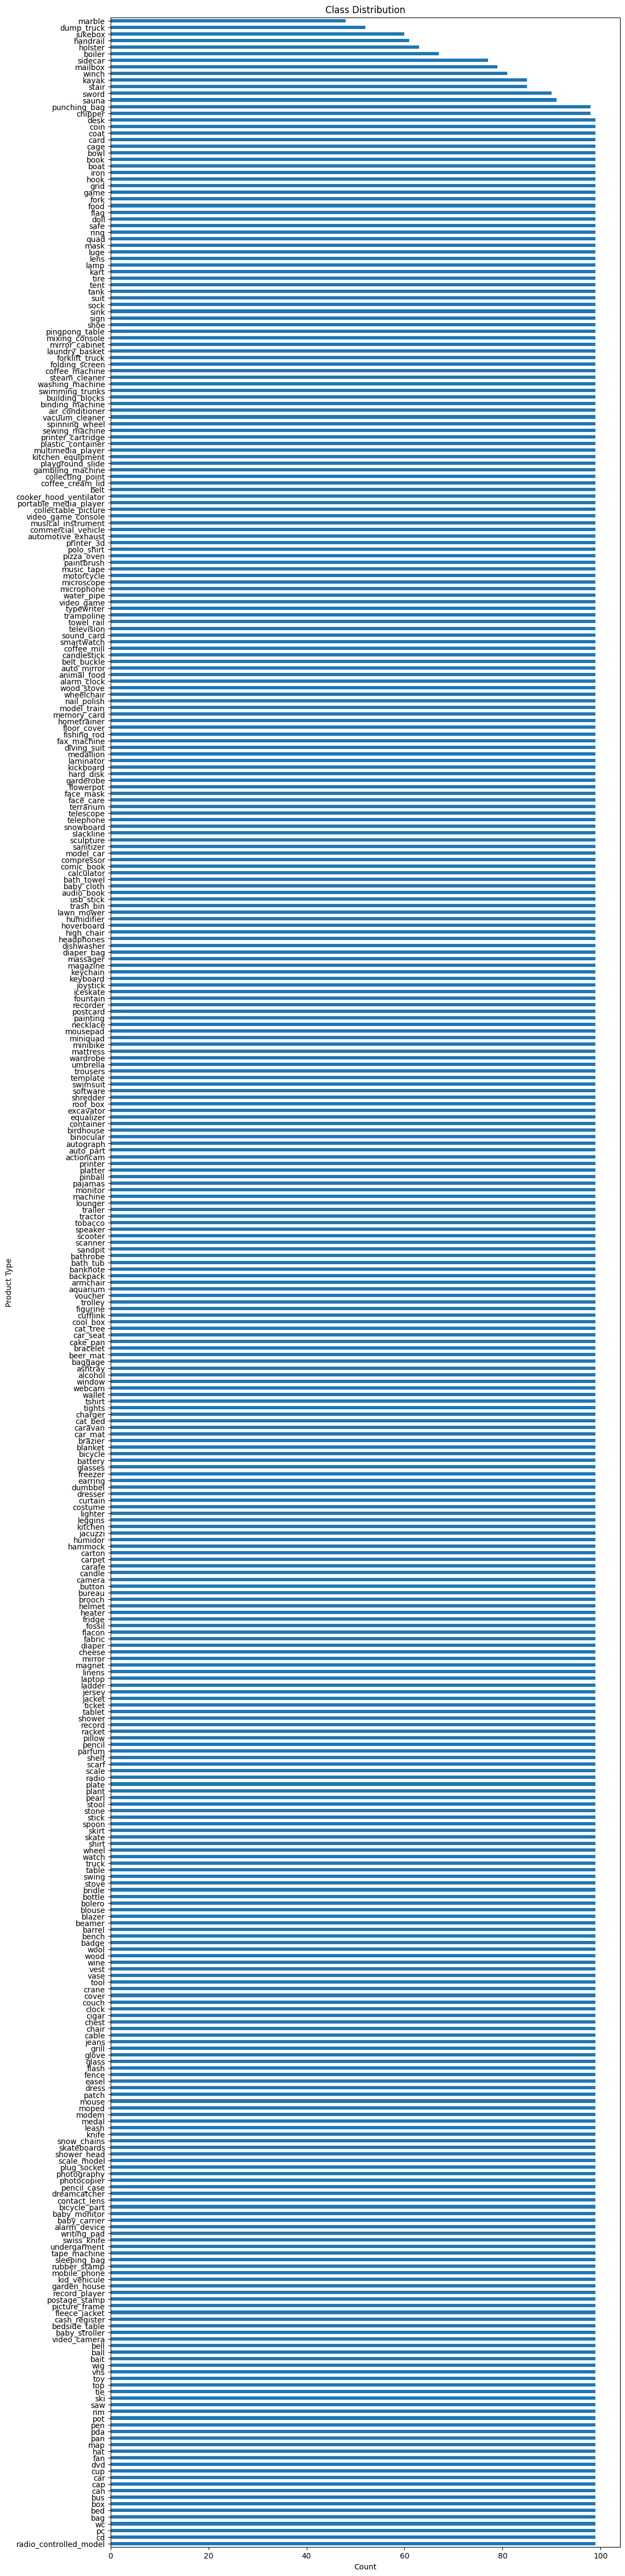

In [12]:
# 1. Class Distribution
plt.figure(figsize=(12, 60))
# horizontal bar chart
df_load['productType'].value_counts().plot(kind='barh')
plt.title('Class Distribution')
plt.xlabel('Count')
plt.ylabel('Product Type')
plt.show()

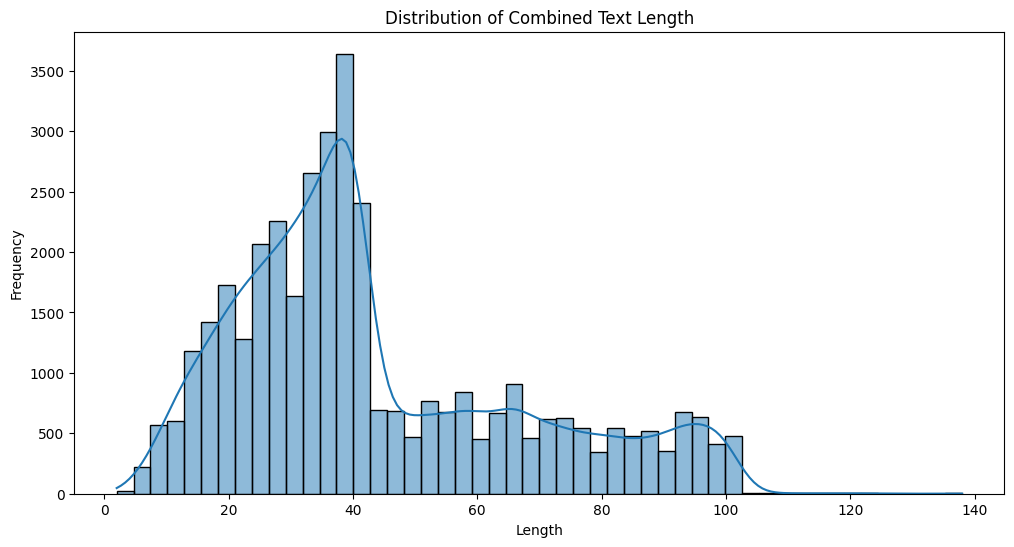

In [18]:
# 2. Text Length Analysis
plt.figure(figsize=(12, 6))
sns.histplot(df_load['combined_length'], bins=50, kde=True)
plt.title('Distribution of Combined Text Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

## Evaluation

In [19]:
# Load model
model = DistilBertForSequenceClassification.from_pretrained('results/checkpoint-76500')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased-finetuned-product-detection')

In [ ]:
# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

predictions = trainer.predict(test_dataset)
print("Weighted F1 Score:", f1_score(y_test, predictions.predictions.argmax(-1), average='weighted'))
print(f"Accuracy: {accuracy_score(y_test, predictions.predictions.argmax(-1))}")
print(f"Precision: {precision_score(y_test, predictions.predictions.argmax(-1), average='weighted')}")
print(f"Recall: {recall_score(y_test, predictions.predictions.argmax(-1), average='weighted')}")
print(f"Confusion Matrix: {confusion_matrix(y_test, predictions.predictions.argmax(-1))}")
print(f"Classification Report: {classification_report(y_test, predictions.predictions.argmax(-1))}")


In [ ]:
# plot confusion matrix
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, predictions.predictions.argmax(-1)), annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')